In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import NeuralNetwork

# **Forward Pass Validation**

This notebook verifies that the neural network is wired correctly before any training happens.

We check:
- Output shapes are correct at each layer
- Probabilities are in (0, 1)
- Loss decreases over a small number of iterations

This is a structural sanity check, not a performance evaluation.

In [2]:
np.random.seed(42)

X = np.random.randn(5, 3)
y = np.array([[1], [0], [1], [0], [1]])

In [3]:
model = NeuralNetwork(
    input_dim=3,
    hidden_dim=4,
    learning_rate=0.01,
    epochs=10
)

## **Shape Check**

Verify the forward pass produces the correct output dimensions.

- `A1` — hidden layer activations: `(n_samples, hidden_dim)`
- `A2` — output probabilities: `(n_samples, 1)`

In [4]:
A1, A2 = model.forward(X)

print("A1 shape:", A1.shape)   # (5, 4)
print("A2 shape:", A2.shape)   # (5, 1)

A1 shape: (5, 4)
A2 shape: (5, 1)


## **Probability Range Check**

Output probabilities must lie in (0, 1).

With small random initialization, outputs should cluster near 0.5 — the model has no signal yet and produces near-uniform predictions.

In [5]:
print("Min prob:", A2.min())
print("Max prob:", A2.max())

Min prob: 0.4999963136963553
Max prob: 0.5000202583623885


## **Loss Check**

Run 10 training iterations and confirm loss is decreasing.

10 epochs is not enough to learn — the goal here is only to confirm that gradients are flowing and parameter updates are moving in the right direction.

In [6]:
model.fit(X, y)

print("Final loss:", model.loss_history[-1])

Final loss: 0.6922593207875266


## **Loss Curve**

Visual confirmation that loss decreases monotonically over the 10 sanity-check iterations.

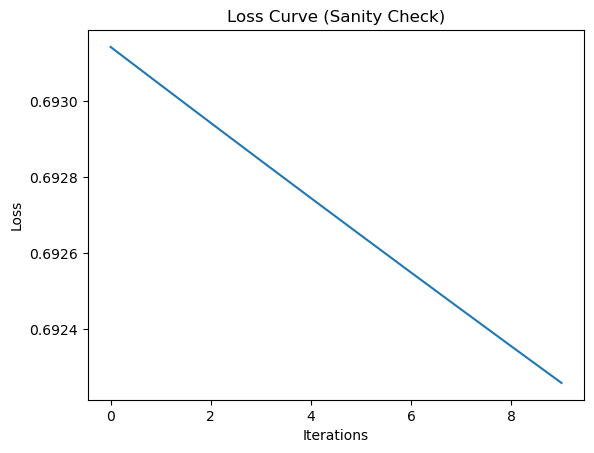

In [7]:
os.makedirs("../experiments", exist_ok=True)
plt.plot(model.loss_history)
plt.title("Loss Curve (Sanity Check)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.savefig("../experiments/nb01_sanity_loss_curve.png")
plt.show()

## **Observations**

- Output shapes match expected dimensions: A1 `(5, 4)`, A2 `(5, 1)`
- Initial probabilities cluster near 0.5, confirming small weight initialization is working as intended
- Loss decreases monotonically over 10 iterations — forward pass, loss computation, and backpropagation are all correctly connected

The network is structurally correct and ready for full training.